In [6]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pulkit8595/movebank-animal-tracking")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\AFRICDSA\.cache\kagglehub\datasets\pulkit8595\movebank-animal-tracking\versions\1


     event-id  visible                timestamp  location-long  location-lat  \
0  1082620685     True  2009-05-27 14:00:00.000       24.58617      61.24783   
1  1082620686     True  2009-05-27 20:00:00.000       24.58217      61.23267   
2  1082620687     True  2009-05-28 05:00:00.000       24.53133      61.18833   
3  1082620688     True  2009-05-28 08:00:00.000       24.58200      61.23283   
4  1082620689     True  2009-05-28 14:00:00.000       24.58250      61.23267   

   manually-marked-outlier  visible.1 sensor-type  \
0                      NaN       True         gps   
1                      NaN       True         gps   
2                      NaN       True         gps   
3                      NaN       True         gps   
4                      NaN       True         gps   

  individual-taxon-canonical-name  tag-local-identifier  \
0                    Larus fuscus                 91732   
1                    Larus fuscus                 91732   
2                    La

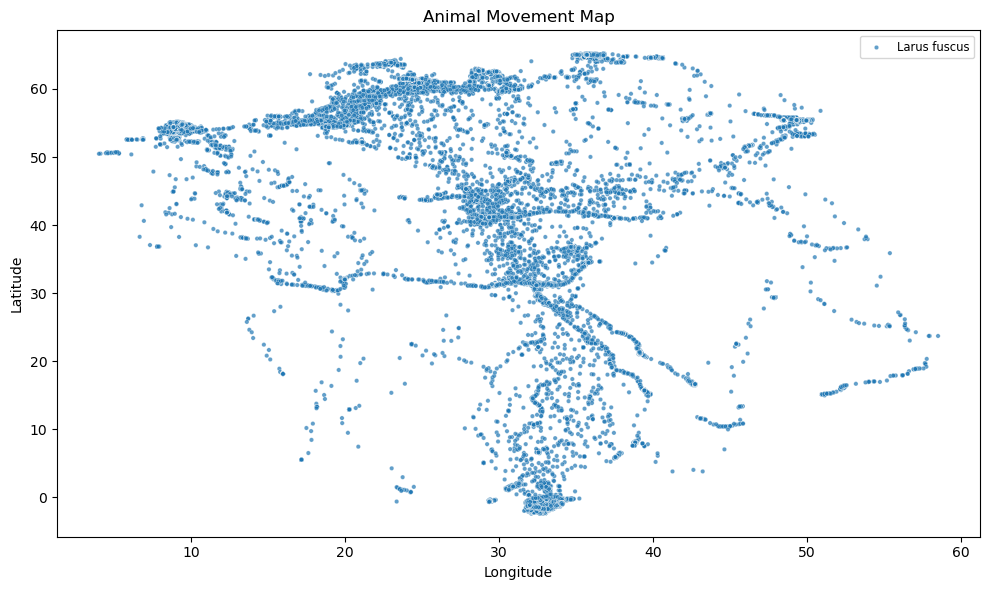

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('c:\\Users\\AFRICDSA\\.cache\\kagglehub\\datasets\\pulkit8595\\movebank-animal-tracking\\versions\\1\\migration_original.csv')  # Adjust the file name if different

# Preview the data
print(data.head())
print("\nData Summary:\n", data.info())

# Check for missing values
missing = data.isnull().sum()
print("\nMissing values:\n", missing)

# Basic statistics
print("\nBasic Statistics:\n", data.describe())

# Convert timestamp column to datetime (if it's in the dataset)
if 'timestamp' in data.columns:
    data['timestamp'] = pd.to_datetime(data['timestamp'])
    data['year'] = data['timestamp'].dt.year
    data['month'] = data['timestamp'].dt.month

# Scatter plot of movement (latitude vs longitude)
if 'location-lat' in data.columns and 'location-long' in data.columns:
    plt.figure(figsize=(10,6))
    sns.scatterplot(
        x='location-long',
        y='location-lat',
        hue='individual-taxon-canonical-name',  # ✅ correct way
        data=data,
        s=10,
        alpha=0.7
    )
    plt.title('Animal Movement Map')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend(loc='best', fontsize='small')
    plt.tight_layout()
    plt.show()



In [ ]:
pip install geopy

C:\Users\AFRICDSA\AppData\Local\Temp\ipykernel_15712\4076757954.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('individual-local-identifier', group_keys=False).apply(calc_distance)


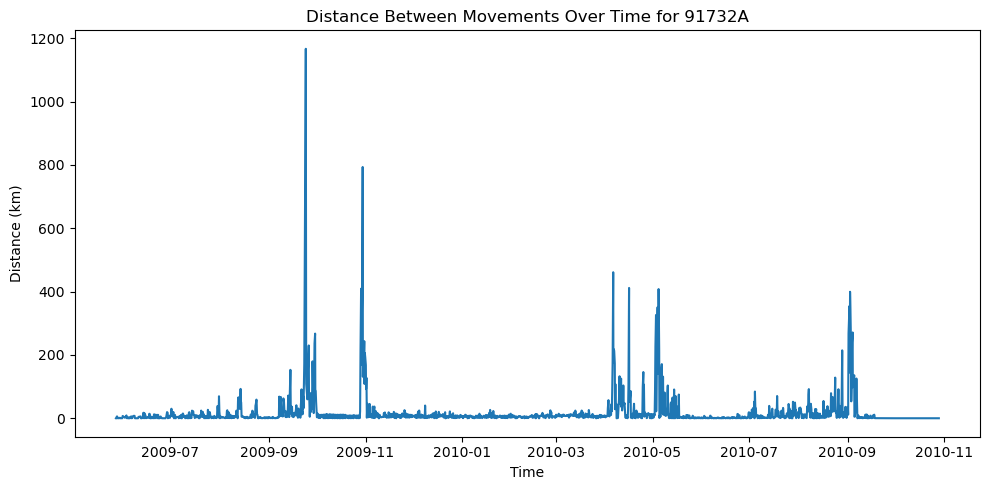

In [16]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import matplotlib.pyplot as plt

# Convert timestamp to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Sort by individual and time
data = data.sort_values(by=['individual-local-identifier', 'timestamp'])

# Calculate distance between consecutive points
def calc_distance(group):
    distances = [0]
    for i in range(1, len(group)):
        prev = (group.iloc[i-1]['location-lat'], group.iloc[i-1]['location-long'])
        curr = (group.iloc[i]['location-lat'], group.iloc[i]['location-long'])
        dist = geodesic(prev, curr).kilometers
        distances.append(dist)
    group['distance_km'] = distances
    return group

# Apply distance calculation for each individual animal
data = data.groupby('individual-local-identifier', group_keys=False).apply(calc_distance)

# Optional: Plot distance over time for one individual
individual = data['individual-local-identifier'].iloc[0]
subset = data[data['individual-local-identifier'] == individual]

plt.figure(figsize=(10,5))
plt.plot(subset['timestamp'], subset['distance_km'])
plt.title(f'Distance Between Movements Over Time for {individual}')
plt.xlabel('Time')
plt.ylabel('Distance (km)')
plt.tight_layout()
plt.show()


In [17]:
import pandas as pd
import numpy as np
import math



# Function to calculate bearing between two coordinates
def calculate_bearing(lat1, lon1, lat2, lon2):
    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    delta_lon = lon2 - lon1
    x = math.sin(delta_lon) * math.cos(lat2)
    y = math.cos(lat1)*math.sin(lat2) - math.sin(lat1)*math.cos(lat2)*math.cos(delta_lon)
    bearing = math.atan2(x, y)
    bearing = math.degrees(bearing)
    return (bearing + 360) % 360

# Calculate direction for each individual
def add_direction(group):
    directions = [np.nan]
    for i in range(1, len(group)):
        lat1, lon1 = group.iloc[i-1]['location-lat'], group.iloc[i-1]['location-long']
        lat2, lon2 = group.iloc[i]['location-lat'], group.iloc[i]['location-long']
        direction = calculate_bearing(lat1, lon1, lat2, lon2)
        directions.append(direction)
    group['direction_deg'] = directions
    return group

data = data.groupby('individual-local-identifier', group_keys=False).apply(add_direction)

# Preview the updated data
print(data[['timestamp', 'location-lat', 'location-long', 'direction_deg']].head())


            timestamp  location-lat  location-long  direction_deg
0 2009-05-27 14:00:00      61.24783       24.58617            NaN
1 2009-05-27 20:00:00      61.23267       24.58217     187.236713
2 2009-05-28 05:00:00      61.18833       24.53133     208.929407
3 2009-05-28 08:00:00      61.23283       24.58200      28.716637
4 2009-05-28 14:00:00      61.23267       24.58250     123.620959


C:\Users\AFRICDSA\AppData\Local\Temp\ipykernel_15712\2722245023.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('individual-local-identifier', group_keys=False).apply(add_direction)


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load and prepare data (assuming you've already calculated direction like before)


# Drop rows with missing direction
data = data.dropna(subset=['direction_deg'])

# Feature engineering — create some lag features to give the model context
data['lat_prev'] = data.groupby('individual-local-identifier')['location-lat'].shift(1)
data['lon_prev'] = data.groupby('individual-local-identifier')['location-long'].shift(1)
data['lat_change'] = data['location-lat'] - data['lat_prev']
data['lon_change'] = data['location-long'] - data['lon_prev']

# Drop missing values after shift
data = data.dropna(subset=['lat_prev', 'lon_prev', 'lat_change', 'lon_change'])

# Select features and target
features = data[['lat_prev', 'lon_prev', 'lat_change', 'lon_change']]
target = data['direction_deg']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Model training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediction and evaluation
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} degrees")
print(f"R-squared Score: {r2:.2f}")


Mean Absolute Error: 0.64 degrees
R-squared Score: 1.00


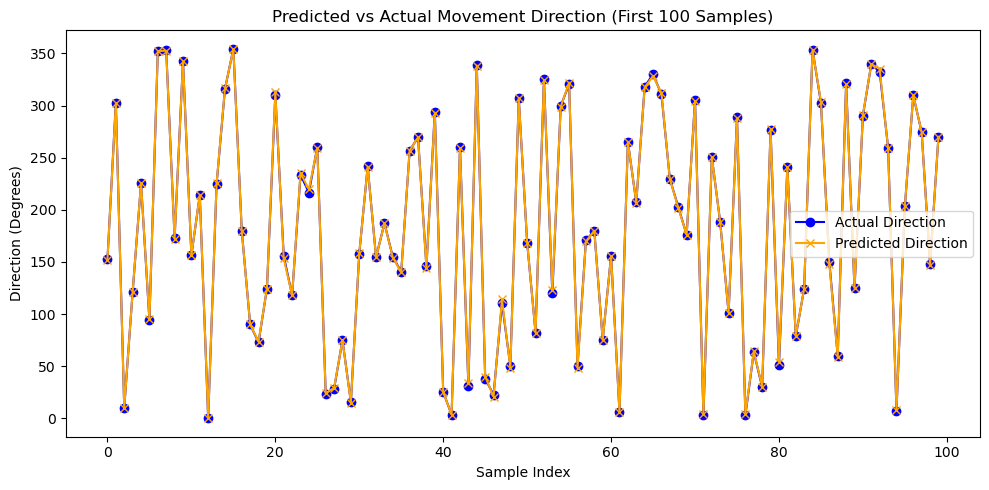

In [19]:
import matplotlib.pyplot as plt

# Plot predicted vs actual directions
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label='Actual Direction', color='blue', marker='o')
plt.plot(y_pred[:100], label='Predicted Direction', color='orange', marker='x')
plt.title('Predicted vs Actual Movement Direction (First 100 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Direction (Degrees)')
plt.legend()
plt.tight_layout()
plt.show()
